In [9]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [1]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# Check Data Module

In [2]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam0
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam1
INFO     | setup | Train Dataset       : 392 samples
INFO     | _get_names | Processing val
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam0
INFO     | _get_names | Track & Cam : MOO09_short_1_updown cam1
INFO     | setup | Validation Dataset  : 392 samples


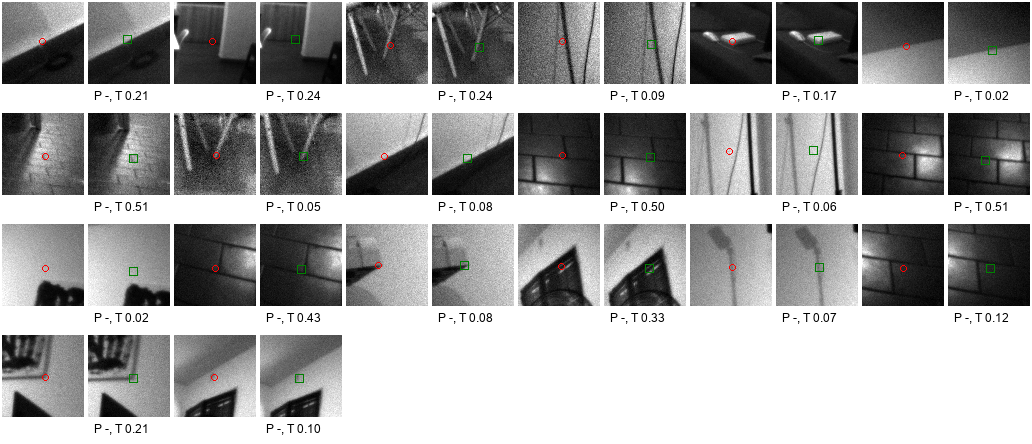

In [3]:
batch = next(iter(dl))
ref_patches, references, tar_patches, targets, confidences, cert, estimates = batch

ref_patches = ref_patches.to(device)
tar_patches = tar_patches.to(device)
references = references.to(device)
estimates = estimates.to(device)

# print(f'{ref_keypoints[:6]=}')
# print(f'{tar_keypoints[:6]=}')

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    references, targets,
    targets,

    confidences_true=confidences,
    
    limit_count=count, 

    n_columns=6,
    just_gt=True,
)

In [4]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _, _ = batch
#         all_confidences.extend(confidences.cpu().numpy())
    
#     all_confidences = np.array(all_confidences)
    
#     # Adjust for skewed distribution by equalizing bins
#     min_conf, max_conf = all_confidences.min(), all_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 30)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(all_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Distribution of Confidence Scores Across All Patches")
#     plt.grid()
#     plt.show()


# dl = dm.train_dataloader()
# plot_confidence_distribution(dl)

# Light

In [10]:
torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

21,027,843


In [11]:
target_coords, target_confidences = light(
    ref_patches, 
    tar_patches, 
    references,
    estimates,
)

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

OutOfMemoryError: CUDA out of memory. Tried to allocate 132.00 MiB. GPU 0 has a total capacity of 3.94 GiB of which 47.62 MiB is free. Including non-PyTorch memory, this process has 3.88 GiB memory in use. Of the allocated memory 3.81 GiB is allocated by PyTorch, and 15.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)